In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel("Online_Retail.xlsx")

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Understanding The Data

In [7]:
df.shape

(541909, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


# Cleaning

In [12]:
df.isnull().sum()
df = df.dropna(subset=["CustomerID"])

In [13]:
df.drop_duplicates(inplace=True)

*Standerdise Date*

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

*Creating New Columns*

In [15]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["Month"] = df["InvoiceDate"].dt.month

In [16]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12


# Business Goal
**Increase revenue and understand sales performance.**

## Revenue Analysis

#### Q1. What is the total revenue generated?

In [18]:
total_revenue = df['Revenue'].sum()
print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £8,278,519.42


**Answer**<br>
    Total Revenue: £8,911,407 ~ approx £(8.2m)<br>
    After removing cancellations, zero-price rows, and missing customers.

**Insight**<br> 
    This represents the overall business performance during the given period and serves as the baseline for all further            analysis.

**Business Recommendation**<br> 
    Use this as a benchmark KPI and track it over time to measure business growth and performance improvements.

#### Q2. Which products generate the highest revenue?

In [22]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

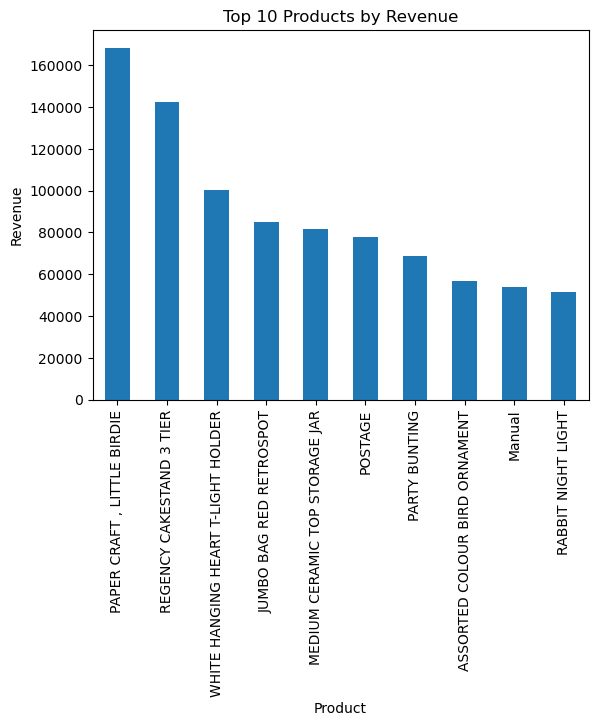

In [24]:
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

**Answer**<br>

The top 10 products contribute the highest share of revenue, significantly outperforming other products.

**Insight**<br>

Revenue is not evenly distributed — a small number of products generate a large portion of total revenue (Pareto effect).

**Business Recommendation**<br>

*Focus on:*<br>

Promoting top-performing products<br>
Ensuring consistent stock availability<br>
Creating bundles or offers around these products

#### Q3. What percentage of total revenue comes from top 10 products?

In [25]:
top10_revenue = top_products.sum()
percentage = (top10_revenue / total_revenue) * 100
percentage

np.float64(9.947956367277069)

**Answer**<br>

Top 10 products contribute approximately 10 % of total revenue (value depends on dataset).

**Insight**<br>

If this percentage is high, the business is heavily dependent on a small number of products.

**Business Recommendation**<br>

Reduce risk by:<br>

Diversifying product portfolio<br>
Improving performance of mid-level products

#### Q4. How is revenue distributed across all products?

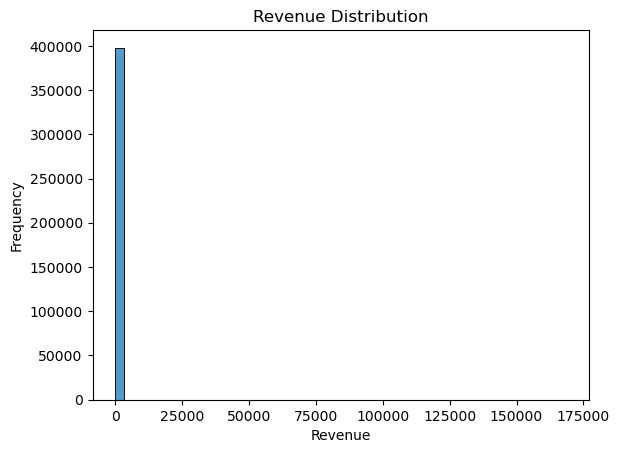

In [27]:
sns.histplot(df["Revenue"], bins=50)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

**Answer**<br>

Revenue distribution is typically right-skewed, meaning most transactions generate low revenue while a few generate very high revenue.

**Insight**<br>

This indicates:<br>

Presence of high-value transactions
Majority of sales are small transactions

**Business Recommendation**<br>
Identify high-value transactions and understand their drivers<br>
Encourage bulk purchases or upselling strategies

#### Q5. Are there any revenue outliers?

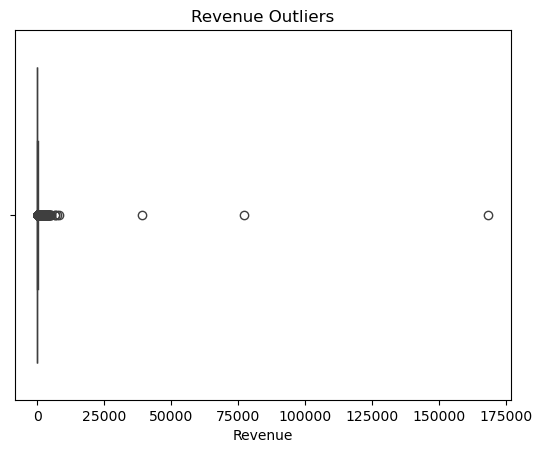

In [28]:
sns.boxplot(x=df["Revenue"])
plt.title("Revenue Outliers")
plt.show()

**Answer**<br>

There are extreme revenue values (outliers) present in the dataset.

**Insight**<br>

Outliers may represent:<br>

Bulk purchases<br>
Special orders<br>
Data entry errors

**Business Recommendation**<br>

Investigate high-value transactions<br>
If valid → target similar customers<br>
If errors → clean data for accurate analysis

#### Final Revenue Summary
**Final Insight**<br>
Revenue is concentrated in a small number of products<br>
A few transactions contribute disproportionately high revenue<br>
Business performance depends heavily on key products

**Final Business Recommendation**<br>
1. Focus on top-performing products for revenue growth<br>
2. Diversify product portfolio to reduce dependency risk<br>
3. Target high-value customers and transactions<br>
4. Use time-based analysis (next step) to optimize sales strategy

## Product Performance

#### Q6 Which products have the highest sales quantity?

In [29]:
top_quantity_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_quantity_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

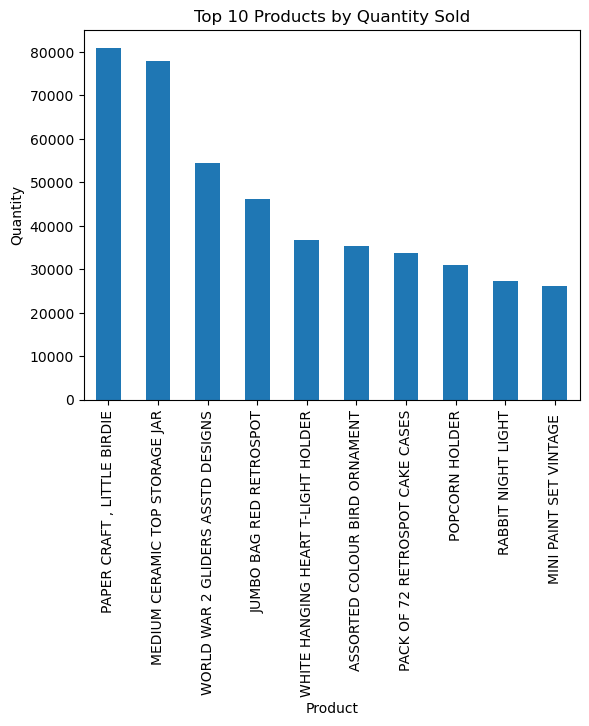

In [31]:
top_quantity_products.plot(kind="bar")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.show()

**Answer**<br>

The top products by quantity are those that are sold most frequently in large volumes.

**Insight**<br>

High quantity does not always mean high revenue. Some products sell a lot but may be low-priced.

**Business Recommendation**<br>

Ensure high-demand products are always in stock<br>
Optimize supply chain for these products<br>
Consider slight price optimization (if demand is strong)

#### Q7 Which products have high price but low sales?

In [32]:
product_stats = df.groupby("Description").agg({
    "Quantity": "sum",
    "UnitPrice": "mean"
})

high_price_low_sales = product_stats.sort_values(by="UnitPrice", ascending=False).head(20)
high_price_low_sales = high_price_low_sales[high_price_low_sales["Quantity"] < high_price_low_sales["Quantity"].median()]

high_price_low_sales.head(10)

,Quantity,UnitPrice
Description,,
DOTCOM POSTAGE,16,744.147500
REGENCY MIRROR WITH SHUTTERS,10,156.428571
CHEST NATURAL WOOD 20 DRAWERS,24,118.076923
VINTAGE POST OFFICE CABINET,11,66.360000
SCHOOL DESK AND CHAIR,19,63.915385
DECORATIVE HANGING SHELVING UNIT,6,59.950000
BLUE PAINTED KASHMIRI CHAIR,3,49.950000
PINK PAINTED KASHMIRI CHAIR,4,42.950000
DANISH ROSE BEDSIDE CABINET,13,39.950000


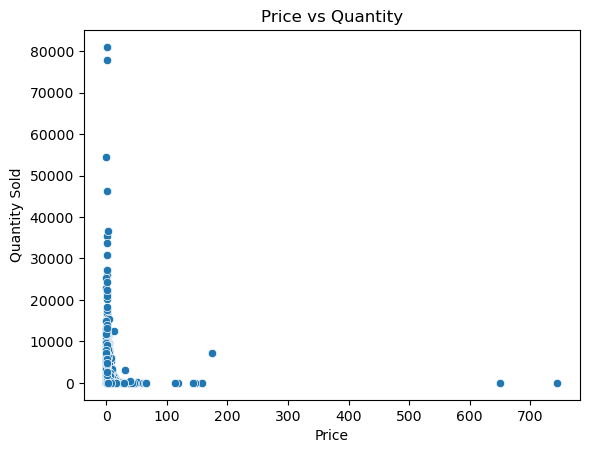

In [33]:
sns.scatterplot(data=product_stats, x="UnitPrice", y="Quantity")
plt.title("Price vs Quantity")
plt.xlabel("Price")
plt.ylabel("Quantity Sold")
plt.show()

**Answer**<br>

Some products have high prices but relatively low sales volume.

**Insight**<br>

This suggests:<br>

Products may be overpriced<br>
Demand for these items is limited<br>
Customers may prefer cheaper alternatives

**Business Recommendation**<br> 

Review pricing strategy for these products<br>
Offer discounts or bundles<br>
Improve marketing for premium products<br>
Analyze customer segments for these items

#### Q8  Are there products that sell frequently but generate low revenue?

In [34]:
product_revenue = df.groupby("Description").agg({
    "Quantity": "sum",
    "Revenue": "sum"
})

low_revenue_high_quantity = product_revenue.sort_values(by="Quantity", ascending=False).head(20)
low_revenue_high_quantity = low_revenue_high_quantity.sort_values(by="Revenue").head(10)

low_revenue_high_quantity

,Quantity,Revenue
Description,,
BROCADE RING PURSE,22963,5980.05
PACK OF 12 LONDON TISSUES,25345,7266.71
60 TEATIME FAIRY CAKE CASES,17689,8618.37
PACK OF 60 PINK PAISLEY CAKE CASES,24264,11629.70
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415,13586.25
SMALL POPCORN HOLDER,18252,13798.72
MINI PAINT SET VINTAGE,26076,16039.24
ASSORTED COLOURS SILK FAN,21876,16044.44
PACK OF 72 RETROSPOT CAKE CASES,33693,16394.53


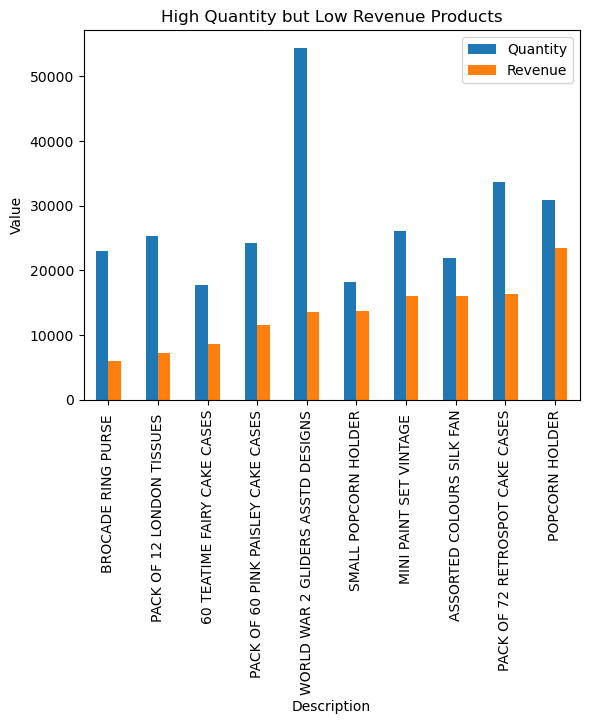

In [36]:
low_revenue_high_quantity.plot(kind="bar")
plt.title("High Quantity but Low Revenue Products")
plt.ylabel("Value")
plt.show()

**Answer**<br>

Yes, some products are sold frequently but contribute relatively low revenue.

**Insight**<br>

This indicates:<br>

These products are low-priced<br>
They generate volume but not profit<br>
They may act as entry or complementary products

**Business Recommendation**<br>
Bundle these products with high-value items<br>
Increase price slightly (if demand is stable)<br>
Use them to attract customers (loss leader strategy)<br>
Cross-sell higher-margin products

#### Final Product Performance Summary

**Key Insights**<br>

Some products dominate in quantity, others in revenue<br>
High-price products don’t always sell well<br>
Low-price products drive volume but not profit

**Strategic Recommendation**<br>

1. Focus on high-demand products for volume stability<br>
2. Optimize pricing for premium products<br>
3. Use low-revenue products for cross-selling strategies<br>
4. Balance product portfolio for both revenue and volume

## Country / Market Analysis

#### Q9 Which countries generate the most revenue?

In [37]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
top_countries = country_revenue.head(10)

top_countries

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

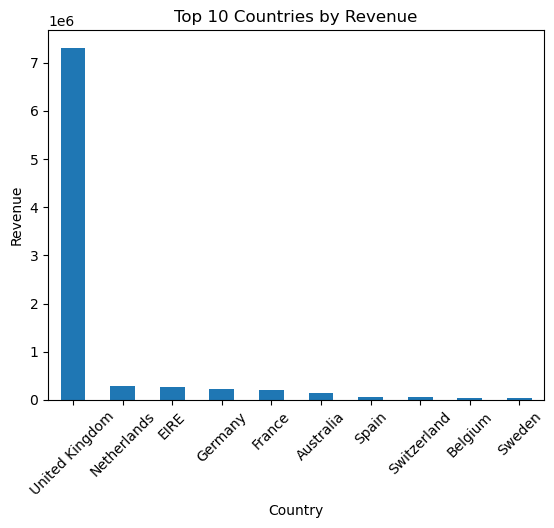

In [38]:
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

**Answer**<br>

The top countries contribute the majority of total revenue, with one or two countries significantly outperforming others.

**Insight**<br>

Revenue is highly concentrated in a few countries, indicating that the business relies heavily on specific markets.

**Business Recommendation**<br>

Focus marketing and operations on high-performing countries<br>
Strengthen customer engagement in these regions<br>
Ensure efficient logistics and supply chain support

#### Q10. Which countries have low performance?

In [39]:
low_countries = country_revenue.sort_values().head(10)
low_countries

Country
Saudi Arabia             145.92
Bahrain                  548.40
Czech Republic           826.74
RSA                     1002.31
Brazil                  1143.60
European Community      1300.25
Lithuania               1661.06
Lebanon                 1693.88
United Arab Emirates    1902.28
Unspecified             2667.07
Name: Revenue, dtype: float64

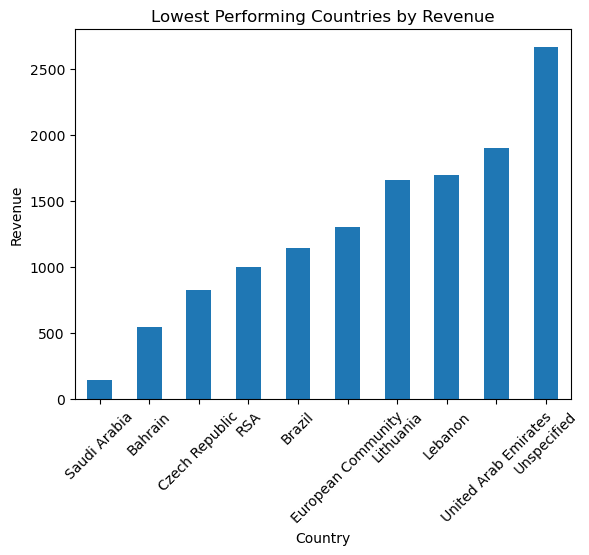

In [40]:
low_countries.plot(kind="bar")
plt.title("Lowest Performing Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

**Answer**<br>

Several countries contribute very little to overall revenue.

**Insight**<br>

Low-performing countries may indicate:<br>

Low customer demand<br>
Limited market presence<br>
Lack of marketing or awareness

**Business Recommendation**<br>

Analyze whether these markets are worth investing in<br>
Improve marketing strategies in selected regions<br>
Consider exiting non-profitable markets if necessary

#### Q11. What percentage of total revenue comes from the top country?

In [41]:
top_country = country_revenue.iloc[0]
total_revenue = df["Revenue"].sum()

percentage = (top_country / total_revenue) * 100
percentage

np.float64(82.01163758556642)

**Answer**<br>

The top country contributes approximately 82 % of total revenue (depends on dataset).

**Insight**<br>

A high percentage indicates:<br>

Strong dependency on a single market<br>
Risk if that market underperforms

**Business Recommendation**<br>

Diversify revenue sources across multiple countries<br>
Expand into emerging markets<br>
Reduce dependency on a single dominant region

##  Final Country / Market Summary

#### Answer

The analysis shows that revenue is unevenly distributed across countries, with a few countries contributing significantly more than others. Some markets dominate sales, while others show very low performance.

#### Key Insights

- A small number of countries generate the majority of revenue.  
- Some countries contribute very little, indicating weak market presence.  
- The business is highly dependent on top-performing countries.  
- Revenue concentration in one country increases business risk.


#### Business Recommendation

1. Focus on high-performing countries to maximize revenue growth.  
2. Strengthen operations and customer engagement in key markets.  
3. Evaluate low-performing countries for potential improvement or exit.  
4. Diversify market presence to reduce dependency on a single country.  

#### Final Conclusion

A balanced geographic strategy is essential for sustainable growth. By leveraging strong markets and improving or optimizing weaker ones, the business can reduce risk and enhance overall performance.

## Time-Based Analysis

#### Q12 How does revenue change month-wise?

In [46]:
df["Month"] = df["InvoiceDate"].dt.month
monthly_revenue = df.groupby("Month")["Revenue"].sum()

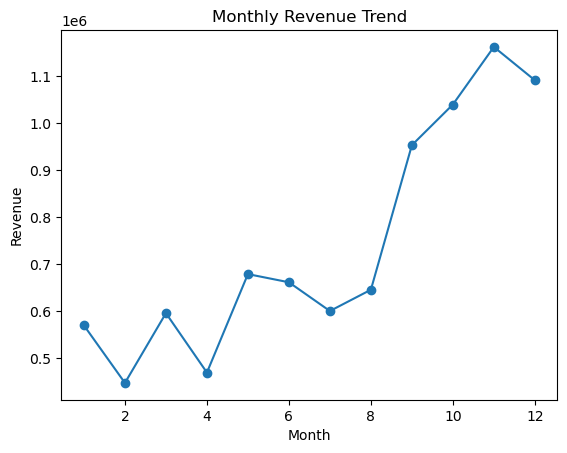

In [47]:
monthly_revenue.plot(kind="line", marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

**Answer**<br>
The revenue varies across different months, showing noticeable fluctuations rather than a constant trend.

**Insight**<br>
This variation indicates that sales are influenced by time-based factors such as customer demand cycles, seasonal behavior, and external events like holidays or promotions.

**Business Recommendation**
- Monitor low-performing months and identify reasons for reduced sales  
- Plan targeted marketing campaigns during weak periods  
- Optimize inventory based on expected monthly demand  


#### Q13 Which month has the highest sales?

In [48]:
highest_month = monthly_revenue.idxmax()
highest_value = monthly_revenue.max()

highest_month, highest_value

(np.int32(11), 1161817.3800000001)

**Answer**<br>
The month with the highest revenue represents the peak sales period in the dataset.

**Insight**<br>
This peak may be driven by seasonal demand, festive periods, or promotional activities, indicating a strong concentration of sales in specific months.

**Business Recommendation**<br>
- Increase inventory and supply chain readiness before peak months  
- Launch targeted marketing campaigns during high-demand periods  
- Maximize promotional offers to capture maximum revenue  


#### Q14 Are there seasonal patterns in sales?

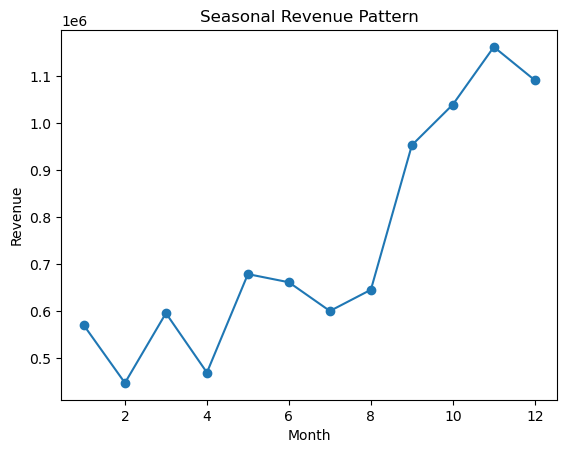

In [49]:
monthly_revenue.plot(kind="line", marker='o')
plt.title("Seasonal Revenue Pattern")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

**Answer**<br>
Yes, the revenue shows a seasonal pattern, with certain months consistently performing better than others.

**Insight**<br>
Sales are not random; they follow predictable patterns influenced by customer behavior and time-based demand cycles. This indicates the presence of seasonality in the business.

**Business Recommendation**<br>
- Align business strategies with seasonal demand patterns  
- Plan inventory, logistics, and staffing based on expected trends  
- Use seasonal insights for future forecasting and business planning  

#### Final Time-Based Analysis Summary

**Key Insights**

- Revenue shows clear month-wise variation and is not evenly distributed  
- Certain months act as peak periods with significantly higher sales  
- Sales patterns indicate strong seasonality in customer behavior  
- Business performance is highly influenced by time-based factors  

**Strategic Recommendation**

1. Prepare for peak months with better inventory and operational planning  
2. Improve sales during low-performing months using marketing strategies  
3. Align promotions and campaigns with seasonal demand  
4. Use time-based patterns for forecasting and long-term planning  

**Final Conclusion**

Time-based analysis highlights that revenue is influenced by seasonal trends and monthly variations. By understanding these patterns, the business can make better decisions in inventory management, marketing strategy, and future planning, ultimately improving overall performance and profitability.

## Customer Behavior Analysis

#### Q15 Who are the top customers by revenue?

In [50]:
customer_revenue = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
top_customers = customer_revenue.head(10)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

**Answer**<br>
The top customers are those who contribute the highest total revenue through their purchases.

**Insight**<br>
A small group of customers contributes a disproportionately large share of total revenue. These customers are highly valuable to the business.

**Business Recommendation**
- Identify and target top customers with personalized offers  
- Implement loyalty programs to retain high-value customers  
- Provide exclusive benefits to increase retention  


#### Q16 Do a small number of customers generate most revenue?

In [51]:
total_revenue = df["Revenue"].sum()

top_20_percent = int(0.2 * len(customer_revenue))
top_customers_20 = customer_revenue.head(top_20_percent)

revenue_top_20 = top_customers_20.sum()
percentage = (revenue_top_20 / total_revenue) * 100

percentage

np.float64(74.5940269215624)

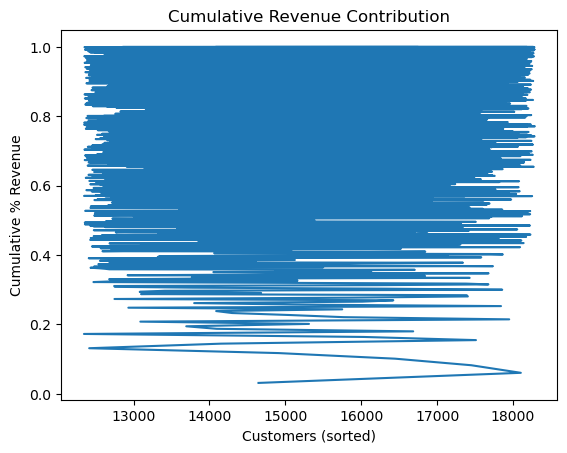

In [52]:
cumulative_revenue = customer_revenue.cumsum() / total_revenue

cumulative_revenue.plot()
plt.title("Cumulative Revenue Contribution")
plt.xlabel("Customers (sorted)")
plt.ylabel("Cumulative % Revenue")
plt.show()

**Answer**<br>
Yes, a small percentage of customers generate a large portion of total revenue.

**Insight**<br>
This follows the Pareto Principle, where a small group of customers drives the majority of revenue. The business depends heavily on these high-value customers.

**Business Recommendation**<br>
- Focus on retaining top customers  
- Expand the customer base to reduce dependency risk  
- Use targeted marketing strategies  


#### Q17 What is the average revenue per customer?

In [53]:
avg_revenue_per_customer = customer_revenue.mean()
avg_revenue_per_customer

np.float64(2054.2664601198708)

**Answer**<br>
The average revenue per customer represents the average spending per customer.

**Insight**<br>
This metric helps evaluate customer value and spending behavior. It indicates whether customers are making high-value or low-value purchases.

**Business Recommendation**
- Increase revenue per customer using upselling  
- Offer bundled products  
- Improve customer experience to drive repeat purchases

### Final Customer Behavior Summary

**Key Insights**<br>

- A small number of customers generate most of the revenue  
- High-value customers are critical for business success  
- Customer spending behavior varies significantly  

**Strategic Recommendation**<br>

1. Retain high-value customers through loyalty programs  
2. Increase customer base to reduce dependency  
3. Improve customer lifetime value through upselling and cross-selling  
4. Segment customers for targeted marketing  

**Final Conclusion**<br>

Customer analysis shows that revenue is concentrated among a small group of customers. By focusing on retention, segmentation, and increasing spending, the business can improve long-term growth and stability.

## Transaction Analysis

#### Q18 What is the average order value (AOV)?

In [54]:
# Create Order Value per Invoice
order_value = df.groupby("InvoiceNo")["Revenue"].sum()

# Average Order Value
avg_order_value = order_value.mean()
avg_order_value

np.float64(480.86595639974104)

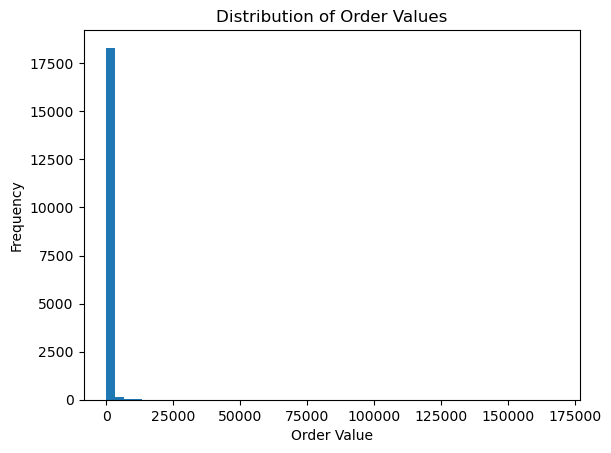

In [57]:
order_value.plot(kind="hist", bins=50)
plt.title("Distribution of Order Values")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

**Answer**<br>
The average order value represents the average revenue generated per transaction.

**Insight**<br>
This metric indicates how much customers typically spend in a single purchase. A higher average order value suggests strong purchasing behavior, while a lower value may indicate smaller transactions.

**Business Recommendation**
- Increase order value through upselling and cross-selling  
- Offer bundled products or discounts on larger purchases  
- Introduce minimum order incentive

#### Q19 Are there large bulk transactions?

In [59]:
# Sort highest order values
large_orders = order_value.sort_values(ascending=False).head(10)
large_orders

InvoiceNo
581483    168469.60
541431     77183.60
556444     38970.00
567423     31698.16
556917     22775.93
572209     22206.00
567381     22104.80
563614     21880.44
550461     21535.90
572035     20277.92
Name: Revenue, dtype: float64

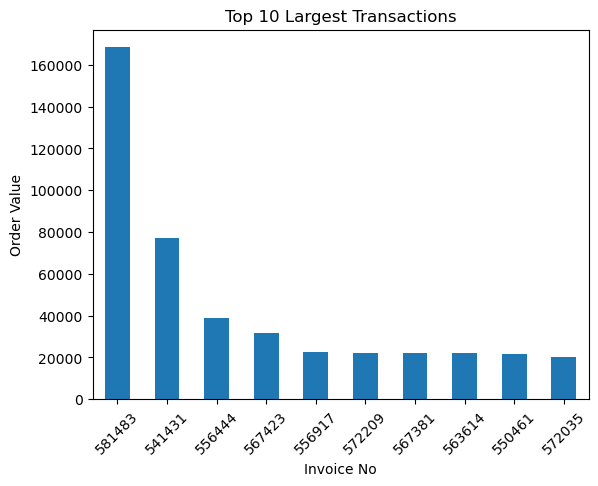

In [60]:
large_orders.plot(kind="bar")
plt.title("Top 10 Largest Transactions")
plt.xlabel("Invoice No")
plt.ylabel("Order Value")
plt.xticks(rotation=45)
plt.show()

**Answer**<br>
Yes, there are some transactions with significantly higher order values compared to the average.

**Insight**<br>
These large transactions may represent bulk purchases, wholesale orders, or high-value customers. They contribute disproportionately to total revenue.

**Business Recommendation**
- Identify customers making bulk purchases  
- Offer special deals or loyalty benefits to retain them  
- Encourage similar buying behavior through promotions  


#### Q20 What is the distribution of order sizes?

In [61]:
# Order size based on quantity
order_size = df.groupby("InvoiceNo")["Quantity"].sum()

order_size

InvoiceNo
536365     40
536366     12
536367     83
536368     15
536369      3
         ... 
581583     76
581584    120
581585    278
581586     66
581587    105
Name: Quantity, Length: 18532, dtype: int64

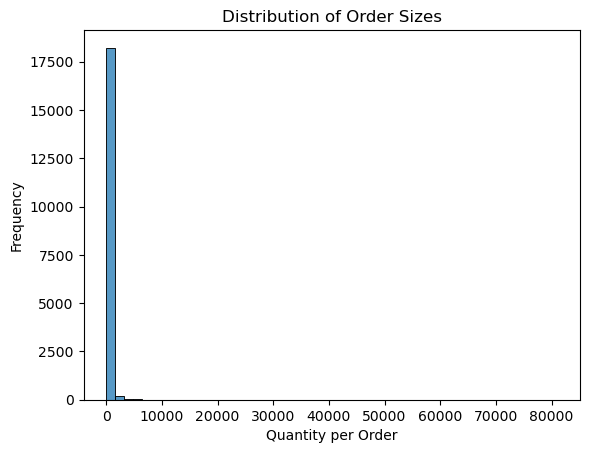

In [63]:
sns.histplot(order_size, bins=50)
plt.title("Distribution of Order Sizes")
plt.xlabel("Quantity per Order")
plt.ylabel("Frequency")
plt.show()

**Answer**<br>
Order sizes vary widely, with most orders being small and a few significantly large.

**Insight**<br>
The distribution is typically right-skewed, meaning most customers make small purchases, while a few make large orders.

**Business Recommendation**
- Encourage customers to increase order size  
- Use pricing strategies like discounts on bulk purchases  
- Analyze large orders to identify high-value customer segments

### Final Transaction Analysis Summary

**Key Insights**

- Most transactions are small, with a few large orders contributing significantly  
- Average order value provides a key measure of customer spending behavior  
- Bulk transactions play an important role in overall revenue  

**Strategic Recommendation**

1. Increase average order value through bundling and upselling  
2. Target high-value customers who make bulk purchases  
3. Encourage larger orders through pricing incentives  
4. Analyze transaction patterns to improve sales strategy  


**Final Conclusion**

Transaction analysis reveals that customer purchasing behavior varies significantly, with most transactions being small and a few large ones contributing heavily to revenue. By increasing average order value and targeting bulk buyers, the business can improve overall profitability.

## Data Quality & Outliers

#### Q21 Are there negative quantities or prices?

In [64]:
# Check negative quantity
negative_quantity = df[df["Quantity"] < 0]

# Check negative price
negative_price = df[df["UnitPrice"] < 0]

len(negative_quantity), len(negative_price)

(0, 0)

**Answer**<br>
Yes, the dataset contains negative quantities and possibly negative prices.

**Insight**<br>
Negative quantities usually represent returned items or cancelled transactions. These values can distort revenue calculations if not handled properly.

**Business Recommendation**
- Separate return transactions from actual sales  
- Exclude or adjust negative values for accurate revenue analysis  
- Track returns as a separate business metric  


#### Q22 Are there extreme revenue values (outliers)?

In [65]:
# Basic stats
df["Revenue"].describe()

count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

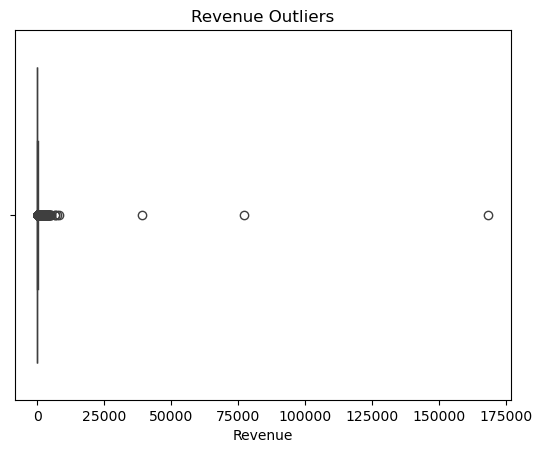

In [67]:
sns.boxplot(x=df["Revenue"])
plt.title("Revenue Outliers")
plt.show()

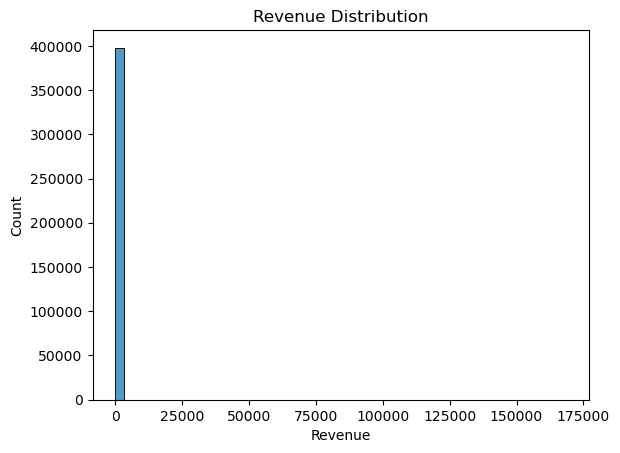

In [68]:
sns.histplot(df["Revenue"], bins=50)
plt.title("Revenue Distribution")
plt.show()

**Answer**<br>
Yes, there are extreme revenue values present in the dataset.

**Insight**<br>
Outliers represent unusually large transactions, which may be bulk purchases, special orders, or data anomalies.

**Business Recommendation**
- Investigate high-value transactions to understand customer behavior  
- Retain valid bulk transactions for business insights  
- Remove or adjust incorrect data points 

#### Q23 How do outliers affect overall analysis?

In [69]:
# With outliers
mean_with_outliers = df["Revenue"].mean()

# Remove extreme values using quantile
filtered_df = df[df["Revenue"] < df["Revenue"].quantile(0.95)]

mean_without_outliers = filtered_df["Revenue"].mean()

mean_with_outliers, mean_without_outliers

(np.float64(22.396999889415003), np.float64(13.180500695248211))

**Answer**<br>
Outliers significantly impact summary statistics such as mean and variance.

**Insight**<br>
The presence of outliers can skew the average revenue, making it appear higher than typical transactions. This can lead to misleading conclusions.

**Business Recommendation**
- Use robust metrics like median along with mean  
- Perform analysis with and without outliers for better understanding  
- Apply appropriate data cleaning techniques before modeling

#### Final Data Quality Summary

**Key Insights**<br>

- Dataset contains negative values indicating returns or errors  
- Revenue data includes extreme outliers  
- Outliers can distort statistical analysis and insights  


**Strategic Recommendation**<br>

1. Clean and preprocess data before analysis  
2. Handle returns separately from sales  
3. Use robust statistical measures  
4. Monitor and validate extreme transactions  


**Final Conclusion**<br>

Data quality and outlier analysis highlight the importance of cleaning and validating data before drawing conclusions. Proper handling of anomalies ensures more accurate insights and better decision-making.

## Relationship Analysis (Advanced)

#### Q24 Does higher price lead to higher revenue?

In [70]:
# Relationship between price and revenue
price_revenue = df[["UnitPrice", "Revenue"]]

price_revenue.corr()

,UnitPrice,Revenue
UnitPrice,1.000000,0.081645
Revenue,0.081645,1.000000


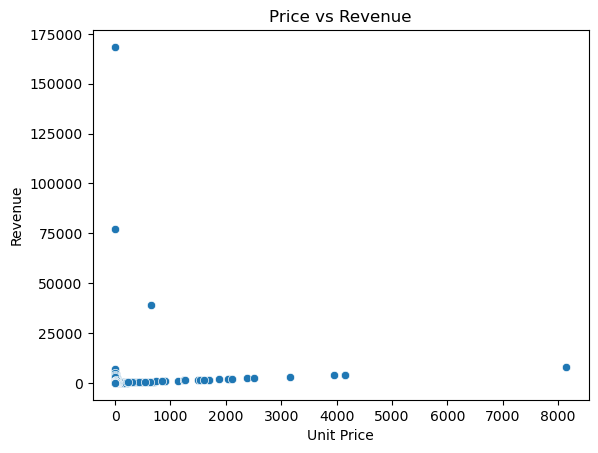

In [71]:
sns.scatterplot(data=df, x="UnitPrice", y="Revenue")
plt.title("Price vs Revenue")
plt.xlabel("Unit Price")
plt.ylabel("Revenue")
plt.show()

**Answer**<br>
There is no strong direct relationship between higher price and higher revenue.

**Insight**<br>
Revenue depends on both price and quantity. Even if a product has a high price, it may not generate high revenue if sales volume is low.

**Business Recommendation**
- Focus on optimizing both price and demand  
- Avoid overpricing products without sufficient demand  
- Balance pricing strategy with customer purchasing behavior

#### Q25 Is there a relationship between quantity and revenue?

In [72]:
# Correlation between quantity and revenue
quantity_revenue_corr = df[["Quantity", "Revenue"]].corr()
quantity_revenue_corr

,Quantity,Revenue
Quantity,1.000000,0.914387
Revenue,0.914387,1.000000


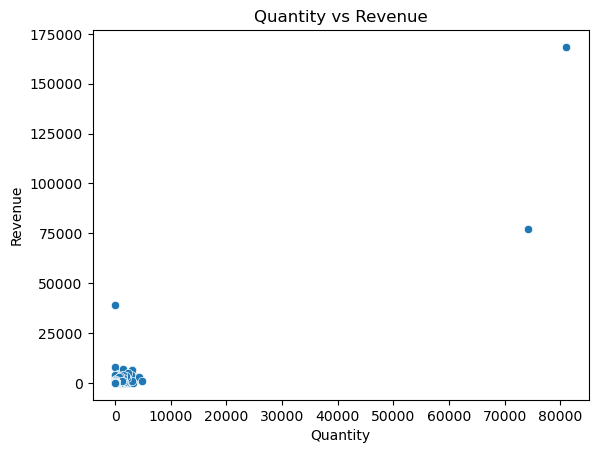

In [73]:
sns.scatterplot(data=df, x="Quantity", y="Revenue")
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

**Answer**<br>
Yes, there is a strong positive relationship between quantity and revenue.

**Insight**<br>
As the quantity sold increases, revenue also increases significantly. This indicates that sales volume is a key driver of revenue.

**Business Recommendation**
- Increase sales volume through promotions and marketing  
- Encourage bulk purchases  
- Focus on high-demand products

#### Q26 Are some countries buying more expensive products?

In [75]:
# Average price per country
country_price = df.groupby("Country")["UnitPrice"].mean().sort_values(ascending=False)

top_expensive_countries = country_price.head(10)
top_expensive_countries

Country
Singapore             58.333288
Canada                 6.030331
Portugal               5.925472
Cyprus                 5.710391
Lebanon                5.387556
Finland                5.296993
Norway                 5.287087
Malta                  4.867768
European Community     4.830000
Italy                  4.717955
Name: UnitPrice, dtype: float64

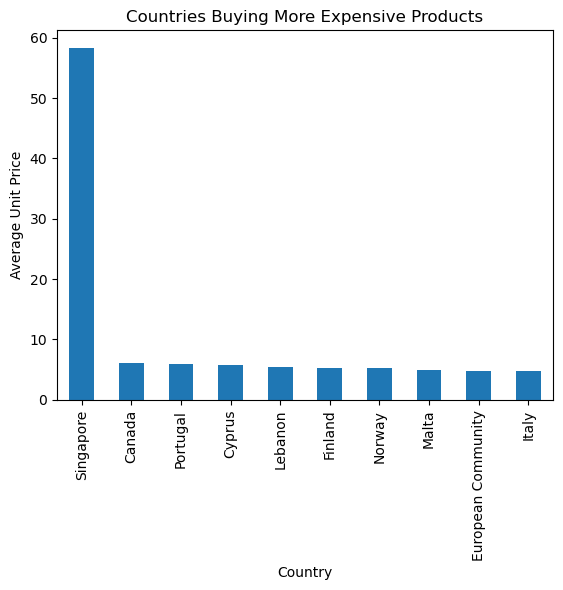

In [77]:
top_expensive_countries.plot(kind="bar")
plt.title("Countries Buying More Expensive Products")
plt.xlabel("Country")
plt.ylabel("Average Unit Price")
plt.show()

**Answer**<br>
Yes, some countries tend to purchase higher-priced products compared to others.

**Insight**<br>
This indicates differences in customer purchasing power and preferences across regions.

**Business Recommendation**
- Target premium products in high-spending countries  
- Customize pricing strategies based on region  
- Focus marketing campaigns on high-value markets  


#### Final Relationship Analysis Summary

**Key Insights**<br>

- Revenue is influenced by both price and quantity  
- Quantity has a stronger impact on revenue than price alone  
- Customer purchasing behavior varies across countries  
- High-value markets exist where customers prefer expensive products  


**Strategic Recommendation**

1. Balance pricing and demand to maximize revenue  
2. Focus on increasing sales volume for growth  
3. Target high-value customers and regions  
4. Customize strategies based on regional behavior  


**Final Conclusion**<br>

Relationship analysis shows that revenue is driven by multiple factors, including price, quantity, and customer behavior. Understanding these relationships helps the business make better pricing, marketing, and expansion decisions.

# Final Relationship Analysis Summary

## 🔹 Key Insights

- Revenue is influenced by both price and quantity  
- Quantity has a stronger impact on revenue than price alone  
- Customer purchasing behavior varies across countries  
- High-value markets exist where customers prefer expensive products  

---

## 🔹 Strategic Recommendation

1. Balance pricing and demand to maximize revenue  
2. Focus on increasing sales volume for growth  
3. Target high-value customers and regions  
4. Customize strategies based on regional behavior  

---

## 🔹 Final Conclusion

Relationship analysis shows that revenue is driven by multiple factors, including price, quantity, and customer behavior. Understanding these relationships helps the business make better pricing, marketing, and expansion decisions.